# 04 · Task2 memory-color decoding

使用灰度水果并进行跨水果验证，避免分类器只学习物体身份。

In [1]:
# [Setup]
from pathlib import Path
import sys, numpy as np, pandas as pd
ROOT=Path('/home/lirui/liulab_project/ieeg/Project_colorieeg_2026'); PIPE=ROOT/'color_cognition_pipeline'/'analyse_0720'
sys.path.insert(0,str(PIPE)); import config
from utils.epochs import load_epochs
from utils.decoding import make_time_windows, decode_accuracy, decode_permutation
from utils.stats import cluster_permutation_1d

In [2]:
# [Data] Candidate electrodes and gray-object labels
cand=pd.read_csv(config.subject_result_dir('test001')/'localizer'/'candidate_electrodes_10mm.csv')
channel_col=next(c for c in cand.columns if c.lower() in ('channel','channelname','name'))
ep=load_epochs(config.INTERMEDIATE_ROOT/'test001'/'preprocessing'/'task2_erp.npz'); names=list(ep['channel_names'])
picks=[names.index(c) for c in cand[channel_col].drop_duplicates() if c in names]
trig=np.char.replace(ep['triggers'].astype(str),'Trigger-In:','')
mask=np.isin(trig,['123','133','103','113']); data=ep['data'][mask][:,picks,:]; selected=trig[mask]
y=np.isin(selected,['103','113']).astype(int)

In [3]:
# [Decode] Cross-fruit folds prevent object-identity leakage
pair_folds=[(('123','103'),('133','113')),(('133','113'),('123','103')),(('123','113'),('133','103')),(('133','103'),('123','113'))]
cv=[]
for train_codes,test_codes in pair_folds:
    train=np.flatnonzero(np.isin(selected,train_codes)); test=np.flatnonzero(np.isin(selected,test_codes)); cv.append((train,test))
windows,centers=make_time_windows(ep['times_ms'],config.WINDOW_MS,config.STEP_MS)
observed=decode_accuracy(data,y,windows,cv)
null=decode_permutation(data,y,windows,cv,config.N_PERMUTATIONS,config.RANDOM_SEED,config.N_JOBS)
p=(1+(null>=observed).sum(0))/(1+len(null)); p_cluster=cluster_permutation_1d(observed,null)
out=config.subject_result_dir('test001')/'task2'
pd.DataFrame({'time_ms':centers,'accuracy':observed,'p_uncorrected':p,'p_cluster':p_cluster}).to_csv(out/'memory_color_decoding.csv',index=False)
np.savez_compressed(out/'memory_color_null.npz',null=null.astype('float32'),time_ms=centers.astype('float32'))

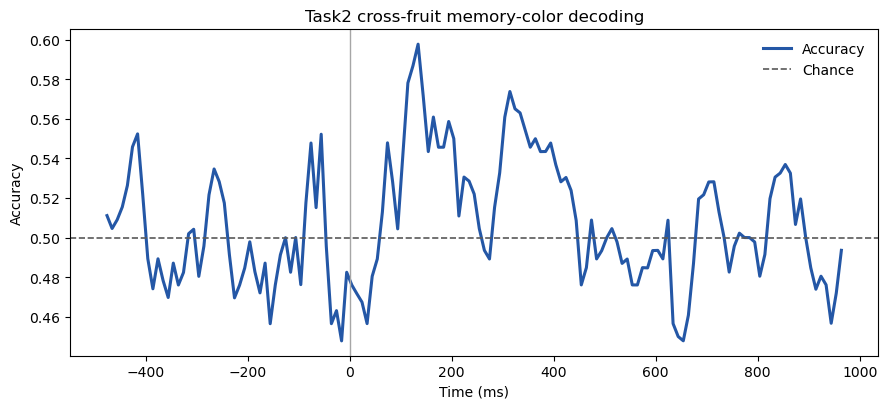

In [4]:
# [Plot] Inline and saved decoding curve
from utils.plotting import plot_decoding
plot_decoding(centers,observed,p_cluster,'Task2 cross-fruit memory-color decoding',out/'memory_color_decoding.png');